# AdamW multiseed run with Nanda Fourier metrics

This notebook mirrors `multiseed_baseline.ipynb`, but enables `fourier_every` so the trainer records restricted/excluded losses, key frequencies, and `W_E` / `W_L` Fourier representation metrics. It also saves sparse model checkpoints at each Fourier snapshot so final-key-frequency analyses can be replayed later.

In [1]:
import os
import importlib
from pathlib import Path

import numpy as np
import torch as t

import model
import pipeline
import plots
import fourier_metrics

importlib.reload(model)
importlib.reload(fourier_metrics)
importlib.reload(pipeline)
importlib.reload(plots)

from model import Config
from pipeline import OptimizerSpec, Trainer

t.manual_seed(0)
np.random.seed(0)

In [2]:
config = Config(
    p=113,
    d_model=128,
    d_mlp=512,
    num_heads=4,
    n_ctx=3,
    act_type='ReLU',
    frac_train=0.3,
    num_epochs=4000, #!25_000,
    seed=0,  # fixed data split, independent of model seeds below
)

specs_adamw = [
    OptimizerSpec(
        'adamw',
        lr=3e-3,
        weight_decay=1.0,
        extra={'betas': (0.9, 0.98)},
    ),
]

SEEDS = [3] #, 1, 2, 3, 4]
SAVE_ROOT = Path('runs/adamw_fourier_metrics')
EVAL_EVERY = 50
FOURIER_EVERY = 500

print(f'CUDA available : {t.cuda.is_available()}')
print(f'MPS available  : {t.backends.mps.is_available()}')
print(f'Device selected: {config.device}')
print(f'Specs  : {specs_adamw[0].describe()}')
print(f'Seeds  : {SEEDS}')
print(f'Save   : {SAVE_ROOT}/seedN/')
print(f'Fourier snapshots every {FOURIER_EVERY} epochs')

CUDA available : False
MPS available  : True
Device selected: mps
Specs  : adamw(ALL, lr=0.003, wd=1.0, betas=(0.9, 0.98))
Seeds  : [3]
Save   : runs/adamw_fourier_metrics/seedN/
Fourier snapshots every 500 epochs


In [3]:
def save_fourier_checkpoint(trainer: Trainer) -> None:
    """Save sparse checkpoints for post-hoc fixed-key-frequency analysis."""
    ckpt_dir = SAVE_ROOT / f'seed{trainer.seed}' / 'fourier_checkpoints'
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    metric_keys = [
        'key_freqs',
        'restricted_loss_test',
        'restricted_acc_test',
        'excluded_all_loss_train',
        'excluded_all_acc_train',
        'gini_W_E',
        'gini_W_L',
        'we_top5_concentration',
        'wl_top5_concentration',
    ]
    metrics = {
        k: trainer.history[k][-1]
        for k in metric_keys
        if k in trainer.history and trainer.history[k]
    }
    t.save(
        {
            'epoch': trainer.epoch,
            'model': trainer.model.state_dict(),
            'metrics': metrics,
        },
        ckpt_dir / f'epoch_{trainer.epoch:06d}.pt',
    )

In [4]:
results = {}
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

for i, seed in enumerate(SEEDS):
    seed_dir = SAVE_ROOT / f'seed{seed}'
    print(f'\n=== adamw_fourier seed {seed} ({i+1}/{len(SEEDS)}) ===')

    if (seed_dir / 'model.pt').exists():
        trainer = Trainer.from_run(
            str(seed_dir),
            specs=specs_adamw,
            fourier_every=FOURIER_EVERY,
        )
        print(f'  loaded existing run at epoch {trainer.epoch}')
    else:
        trainer = Trainer(
            config,
            specs_adamw,
            seed=seed,
            label=f'adamw_fourier_seed{seed}',
            eval_every=EVAL_EVERY,
            fourier_every=FOURIER_EVERY,
            warmup_steps=10,
            verbose_every=2000,
            verbose_build=False,
        )

    if trainer.epoch < config.num_epochs:
        trainer.register_callback('on_fourier_snapshot', save_fourier_checkpoint)
        trainer.fit(config.num_epochs)
        trainer.save_run(str(seed_dir))
        print(f'  saved to {seed_dir}/')

    results[seed] = trainer

print(f'\nTotal seeds available: {len(results)}')


=== adamw_fourier seed 3 (1/1) ===
  [adamw_fourier_seed3 seed=3] epoch     0 | train acc 0.008 | test acc 0.008
  [adamw_fourier_seed3 seed=3] epoch  2000 | train acc 1.000 | test acc 1.000
  [adamw_fourier_seed3 seed=3] epoch  4000 | train acc 1.000 | test acc 1.000
  saved to runs/adamw_fourier_metrics/seed3/

Total seeds available: 1


In [5]:
def first_epoch_above(history, key, threshold):
    for epoch, value in zip(history['epoch'], history[key]):
        if value >= threshold:
            return epoch
    return None

for seed in sorted(results):
    h = results[seed].history
    t_mem = first_epoch_above(h, 'train_acc', 0.99)
    t_grok = first_epoch_above(h, 'test_acc', 0.99)
    last_fourier = h['fourier_epoch'][-1] if h.get('fourier_epoch') else None
    key_freqs = h['key_freqs'][-1] if h.get('key_freqs') else []
    restricted_test = h['restricted_loss_test'][-1] if h.get('restricted_loss_test') else None
    excluded_train = h['excluded_all_loss_train'][-1] if h.get('excluded_all_loss_train') else None
    print(
        f'seed={seed} '
        f'T_mem={t_mem} T_grok={t_grok} '
        f'final_test_acc={h["test_acc"][-1]:.3f} '
        f'last_fourier={last_fourier} '
        f'key_freqs={key_freqs} '
        f'restricted_test={restricted_test} '
        f'excluded_train={excluded_train}'
    )

seed=3 T_mem=100 T_grok=1550 final_test_acc=1.000 last_fourier=4000 key_freqs=[7, 9, 27, 41, 49] restricted_test=9.751182972195238e-08 excluded_train=10.075241088867188


In [6]:
plots.plot_seeds_overlay(
    results,
    title='AdamW baseline with Fourier metrics',
    aggregate='mean',
)

In [7]:
seed_to_plot = sorted(results)[0]
plots.plot_fourier_loss_comparison(
    results[seed_to_plot],
    title=f'Nanda Fourier progress losses — seed {seed_to_plot}',
)


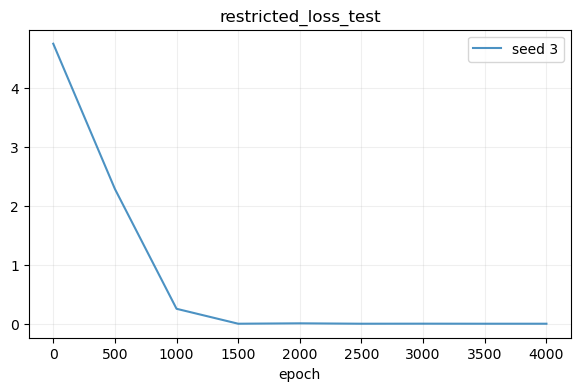

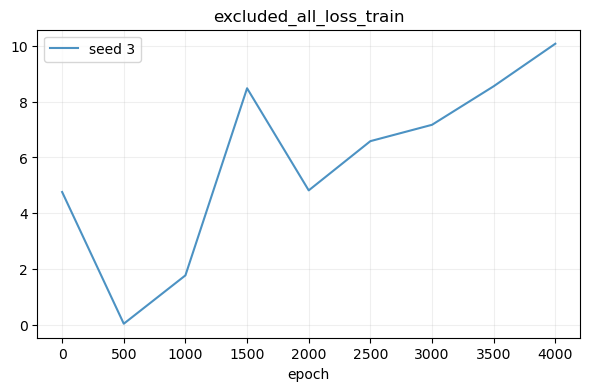

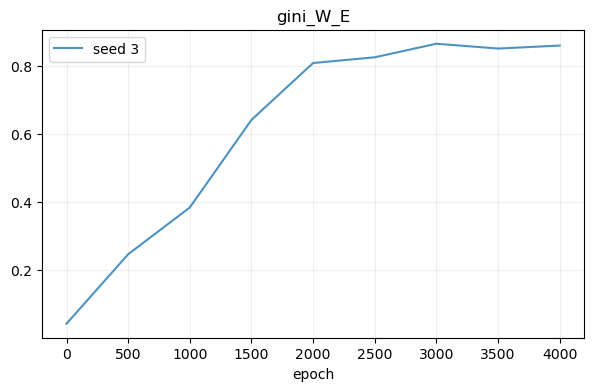

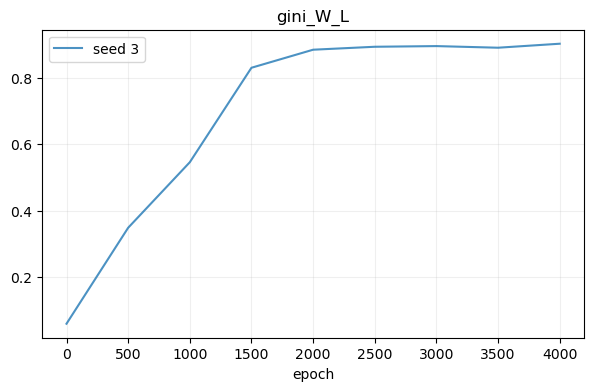

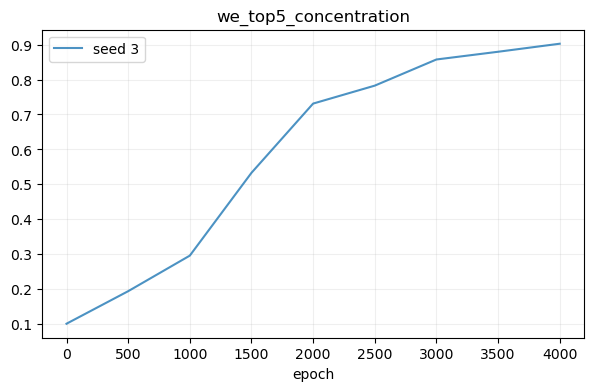

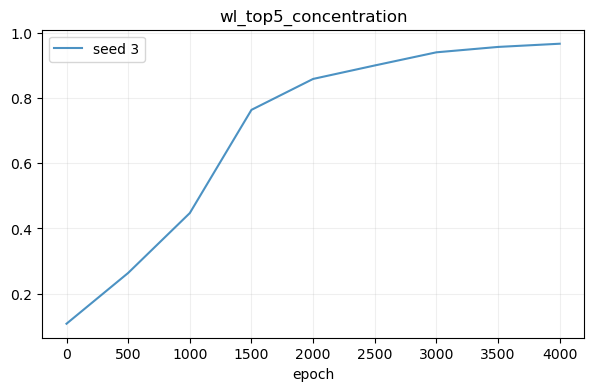

In [8]:
import matplotlib.pyplot as plt

for metric in [
    'restricted_loss_test',
    'excluded_all_loss_train',
    'gini_W_E',
    'gini_W_L',
    'we_top5_concentration',
    'wl_top5_concentration',
]:
    plt.figure(figsize=(7, 4))
    for seed, trainer in sorted(results.items()):
        h = trainer.history
        if h.get('fourier_epoch') and h.get(metric):
            plt.plot(h['fourier_epoch'], h[metric], label=f'seed {seed}', alpha=0.8)
    plt.title(metric)
    plt.xlabel('epoch')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

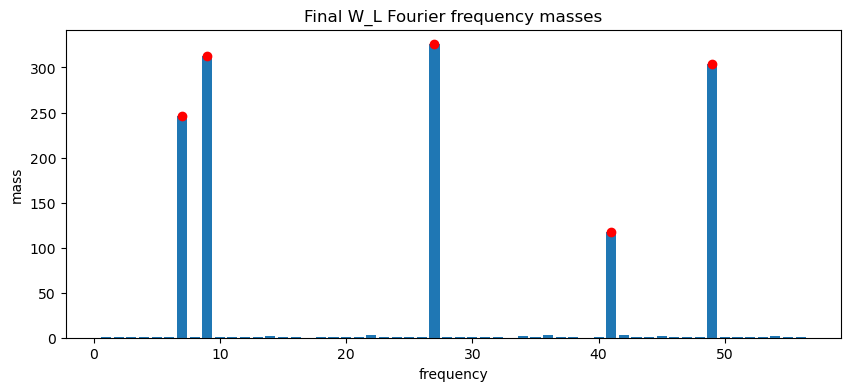

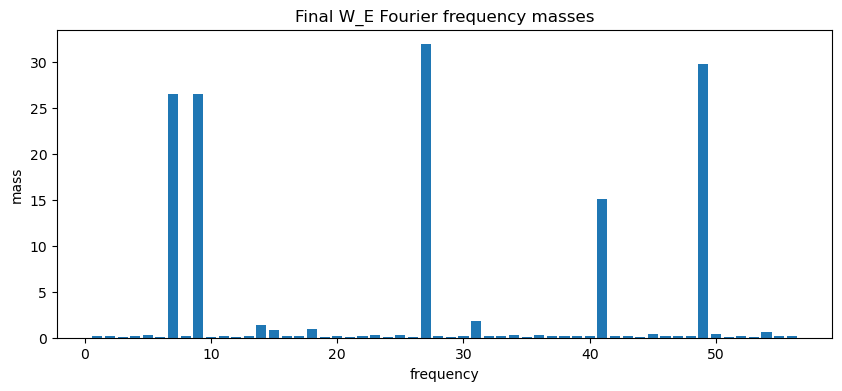

In [9]:
import matplotlib.pyplot as plt
import numpy as np

seed_to_plot = sorted(results)[0]
h = results[seed_to_plot].history
freqs = np.arange(1, len(h["wl_frequency_masses"][-1]) + 1)

plt.figure(figsize=(10, 4))
plt.bar(freqs, h["wl_frequency_masses"][-1])
plt.scatter(h["key_freqs"][-1],
            [h["wl_frequency_masses"][-1][k-1] for k in h["key_freqs"][-1]],
            color="red", zorder=3)
plt.title("Final W_L Fourier frequency masses")
plt.xlabel("frequency")
plt.ylabel("mass")
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(freqs, h["we_frequency_masses"][-1])
plt.title("Final W_E Fourier frequency masses")
plt.xlabel("frequency")
plt.ylabel("mass")
plt.show()

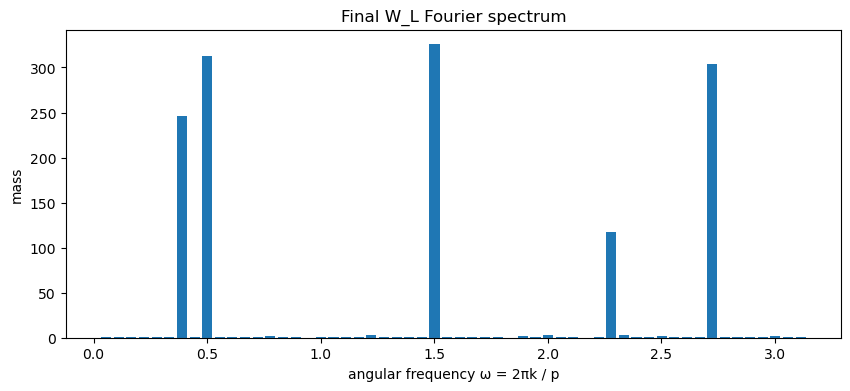

In [10]:
p = config.p
freqs = np.arange(1, len(h["wl_frequency_masses"][-1]) + 1)
omega = 2 * np.pi * freqs / p

plt.figure(figsize=(10, 4))
plt.bar(omega, h["wl_frequency_masses"][-1], width=2*np.pi/p * 0.8)
plt.xlabel("angular frequency ω = 2πk / p")
plt.ylabel("mass")
plt.title("Final W_L Fourier spectrum")
plt.show()